# Single pixel test

**Setup:** A single healpix pixel (point source) sky, Gaussian beam (σ=20°), observer near the lunar equator. Each simulation spans one lunar sidereal day (~27.3 Earth days).

In [18]:
from functools import partial

import jax

jax.config.update("jax_enable_x64", True)

import astropy.units as u
import healpy as hp
import jax.numpy as jnp
import lunarsky
import matplotlib.pyplot as plt
import numpy as np
import s2fft

import croissant as cro

%matplotlib inline

In [19]:
# === Sky parameters ===
nside = 32
npix = 12 * nside**2
lmax = 2 * nside
freq = jnp.array([50.0])  # single frequency in MHz

# === Beam parameters ===
sigma_deg = 20.0
sigma = np.radians(sigma_deg)

# === Observer: near lunar equator ===
obs_lat = 5.0  # degrees
obs_lon = 0.0  # degrees

# === Time: one lunar sidereal day ===
T_sid = cro.constants.sidereal_day["moon"]  # seconds
N_times = 500
dt_sec = jnp.linspace(0, T_sid, N_times)
dt_days = np.array(dt_sec) / 86400

# Arbitrary start time (Julian Date)
t0_jd = 2460010.0

print(
    f"Lunar sidereal day: {T_sid / 3600:.1f} hours = {T_sid / 86400:.2f} days"
)
print(f"lmax = {lmax}, nside = {nside}, npix = {npix}")

Lunar sidereal day: 655.7 hours = 27.32 days
lmax = 64, nside = 32, npix = 12288


## Create Sky and Beam

**Sky:** Single healpix pixel = 1 near the MCMF equator at ~60° east longitude. All other pixels = 0. Defined directly in MCMF coordinates (no galactic→MCMF rotation needed).

**Beam:** Azimuthally symmetric Gaussian with σ=20°, centered at zenith, on the `mwss` grid. Horizon-masked (only upper hemisphere).

In [20]:
theta_hp = cro.utils.generate_theta(sampling="healpix", nside=nside)
phi_hp = cro.utils.generate_phi(sampling="healpix", nside=nside)

target_theta = np.pi / 2  # equator
target_phi = np.pi / 3  # 60° east

cos_dist = np.sin(target_theta) * np.sin(theta_hp) * np.cos(
    phi_hp - target_phi
) + np.cos(target_theta) * np.cos(theta_hp)
angular_dist = np.arccos(np.clip(cos_dist, -1, 1))
source_pixel = int(np.argmin(angular_dist))
source_theta = theta_hp[source_pixel]
source_phi = phi_hp[source_pixel]

print(f"Source pixel: {source_pixel}")
print(
    f"Source position: theta = {np.degrees(source_theta):.1f}°, "
    f"phi = {np.degrees(source_phi):.1f}°"
)
print(
    f"Source MCMF lat = {90 - np.degrees(source_theta):.1f}°, "
    f"lon = {np.degrees(source_phi):.1f}°"
)

sky_data = jnp.zeros((1, npix))
sky_data = sky_data.at[0, source_pixel].set(1.0)

Source pixel: 6101
Source position: theta = 90.0°, phi = 60.5°
Source MCMF lat = 0.0°, lon = 60.5°


In [21]:
# --- Gaussian beam on mwss grid ---
theta_b = cro.utils.generate_theta(lmax=lmax, sampling="mwss")
phi_b = cro.utils.generate_phi(lmax=lmax, sampling="mwss")
theta_grid, phi_grid = np.meshgrid(theta_b, phi_b, indexing="ij")

# Gaussian centered at zenith (theta=0)
beam_pattern = np.exp(-(theta_grid**2) / (2 * sigma**2))
beam_data = jnp.array(beam_pattern[None])  # shape (1, ntheta, nphi)

# Horizon mask: theta <= pi/2
horizon = theta_grid <= np.pi / 2
beam_above = beam_data * jnp.array(horizon[None])

# Beam normalization: integral of FULL beam over sphere (no horizon mask)
# This matches what Simulator.sim() does via Beam.compute_norm()
wgts = s2fft.utils.quadrature_jax.quad_weights(L=lmax + 1, sampling="mwss")
beam_norm = jnp.einsum("ftp,t->f", beam_data, wgts)
print(f"Beam normalization (full sphere integral): {beam_norm}")

Beam normalization (full sphere integral): [0.73523701]


In [22]:
# --- Compute spherical harmonic coefficients ---
sky_mepa = cro.sphere.compute_alm(
    sky_data, lmax, "healpix", nside=nside, niter=3
)
beam_alm_topo = cro.sphere.compute_alm(beam_above, lmax, "mwss")

In [26]:
# rotate beam
loc = lunarsky.MoonLocation(lon=obs_lon, lat=obs_lat)
t0 = lunarsky.Time(t0_jd, format="jd")
topo = lunarsky.LunarTopo(obstime=t0, location=loc)
eul_topo, dl_topo = cro.rotations.generate_euler_dl(lmax, topo, "mepa")
topo2mepa = partial(
    s2fft.utils.rotation.rotate_flms,
    L=lmax + 1,
    rotation=eul_topo,
    dl_array=dl_topo,
)
beam_mepa = jax.vmap(topo2mepa)(beam_alm_topo)

# 7 days later
topo = lunarsky.LunarTopo(obstime=t0 + 7 * u.day, location=loc)
eul_topo, dl_topo = cro.rotations.generate_euler_dl(lmax, topo, "mepa")
topo2mepa = partial(
    s2fft.utils.rotation.rotate_flms,
    L=lmax + 1,
    rotation=eul_topo,
    dl_array=dl_topo,
)
beam_mepa_7d = jax.vmap(topo2mepa)(beam_alm_topo)

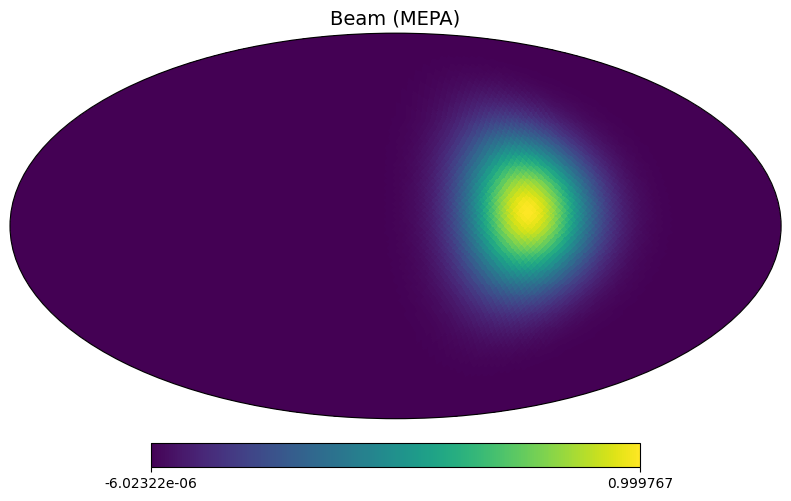

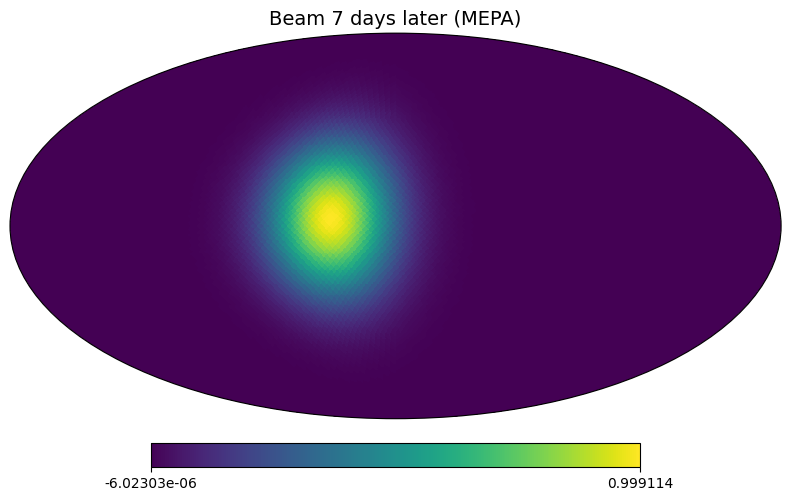

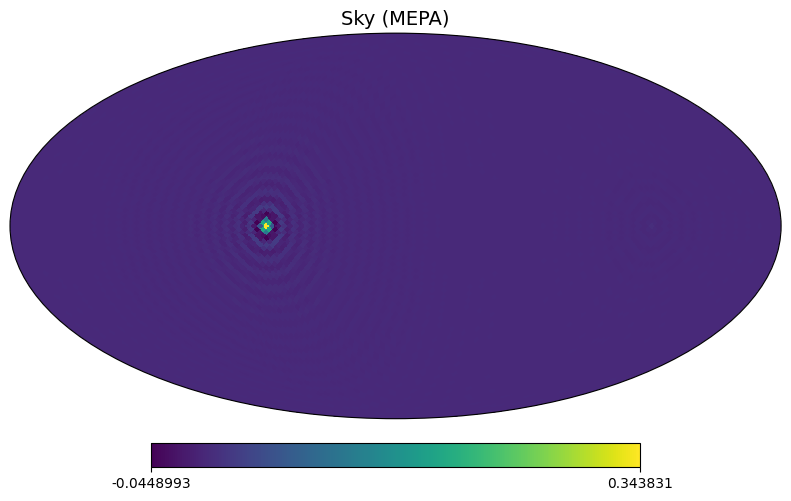

In [27]:
# beam and sky as seen by simulator after transformed back to healpix
beam_reconstructed = s2fft.inverse_jax(
    beam_mepa[0],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
).real
beam7d_reconstructed = s2fft.inverse_jax(
    beam_mepa_7d[0],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    reality=True,
).real
sky_reconstructed = s2fft.inverse(
    sky_mepa[0],
    L=lmax + 1,
    spin=0,
    nside=nside,
    sampling="healpix",
    method="jax_healpy",
    reality=True,
).real

hp.projview(m=beam_reconstructed, title="Beam (MEPA)")
hp.projview(m=beam7d_reconstructed, title="Beam 7 days later (MEPA)")
hp.projview(m=sky_reconstructed, title="Sky (MEPA)")
plt.show()

In [28]:
phases = cro.simulator.rot_alm_z(lmax, times=dt_sec)

vis = cro.simulator.convolve(beam_mepa, sky_mepa, phases)
vis = vis / beam_norm[None, :]

vis7d = cro.simulator.convolve(beam_mepa_7d, sky_mepa, phases)
vis7d = vis7d / beam_norm[None, :]

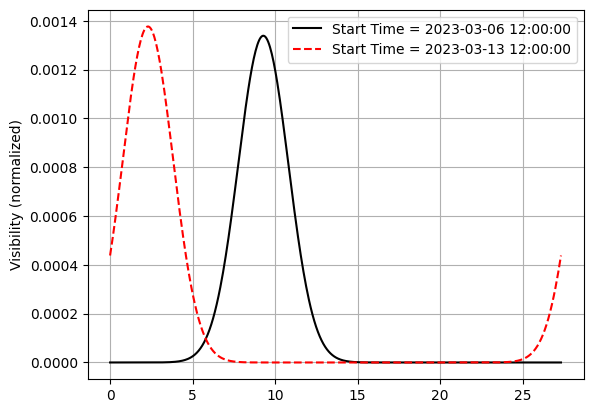

In [29]:
fig, ax = plt.subplots()
ax.plot(
    dt_days,
    np.array(vis[:, 0]),
    "k-",
    lw=1.5,
    label=f"Start Time = {t0.to_datetime()}",
)
ax.plot(
    dt_days,
    np.array(vis7d[:, 0]),
    "r--",
    lw=1.5,
    label=f"Start Time = {(t0 + 7 * u.day).to_datetime()}",
)
ax.set_ylabel("Visibility (normalized)")
ax.legend()
ax.grid()
plt.show()